In [1]:
import pandas as pd
import yfinance as yf
import datetime as dt

In [2]:
start=dt.datetime(2020,1,1)
end=dt.datetime(2023,12,31)
stk_data=yf.download("RELIANCE.NS",start="2020-1-1",end="2023-12-31")

[*********************100%***********************]  1 of 1 completed


In [3]:
stk_data.columns=stk_data.columns.get_level_values(0)

In [4]:
stk_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [5]:
stk_data=stk_data[["Open","High","Low","Close"]]
stk_data

Price,Open,High,Low,Close
Date,,,,
2020-01-01,675.956671,680.008852,670.390532,672.216187
2020-01-02,673.284921,686.176208,673.284921,683.660278
2020-01-03,682.636062,686.487896,678.183128,684.484070
2020-01-06,676.847322,680.365106,667.050830,668.609375
2020-01-07,676.401934,683.304036,673.952826,678.895630
...,...,...,...,...
2023-12-22,1264.550414,1275.073416,1258.646514,1267.242920
2023-12-26,1268.700379,1280.532666,1266.081931,1273.665527
2023-12-27,1275.617031,1284.460338,1271.220103,1278.013184


In [6]:
stk_data.to_csv("RELIANCE.NS.csv")

In [7]:
column="Close"

In [8]:
from sklearn.preprocessing import MinMaxScaler
ms=MinMaxScaler()
data1=ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (992, 1)


In [9]:
len(data1)

992

In [10]:
training_size=round(len(data1)*0.95)
print(training_size)
x_train=data1[:training_size]
x_test=data1[training_size:]
print("X_train length:",x_train.shape)
print("X_test length:",x_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

942
X_train length: (942, 1)
X_test length: (50, 1)
y_train length: (942, 1)
y_test length: (50, 1)


In [11]:
orders=[(1,1,1),(1,1,2),(2,3,1),(2,2,2)]
trends=['n','t','c','ct']
for td in trends:
        from statsmodels.tsa.arima.model import ARIMA
        model=ARIMA(x_train,trend=td)
        model_fit=model.fit()
    
        y_pred=model_fit.predict(len(x_train),len(data1)-1)
    
        from sklearn.metrics import mean_squared_error
        from sklearn.metrics import r2_score
        mse=mean_squared_error(y_test,y_pred)
        from stockFunctions import rmsemape
        print("Trend={}:".format(td))
        rmsemape(y_test,y_pred)
        print("************")
       

Trend=n:
RMSE-Testset: 0.8830996962499624
MAPE-Testset: 1.0
************
Trend=t:
RMSE-Testset: 0.32261309485322837
MAPE-Testset: 0.3673543231266389
************
Trend=c:
RMSE-Testset: 0.2036996411231154
MAPE-Testset: 0.2198872881930213
************
Trend=ct:
RMSE-Testset: 0.1180526789548667
MAPE-Testset: 0.12693569905246524
************


In [12]:
len(y_pred)

50

In [23]:
td="ct"
model = ARIMA(x_train,order=(1,0,5),trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(x_train), len(data1)-1)
#print(y_pred)
from sklearn.metrics import r2_score
mse=mean_squared_error(y_test,y_pred)
from stockFunctions import rmsemape
print("Trend={}".format(td))
rmsemape(y_test,y_pred)
print("************")

Trend=ct
RMSE-Testset: 0.03730052163399859
MAPE-Testset: 0.03756455398800317
************


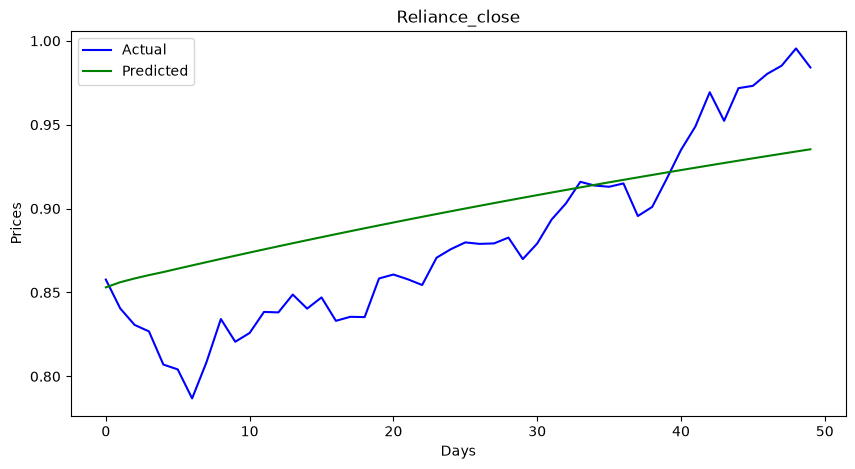

In [24]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","Reliance_close","Days","Prices")

In [31]:
from stockFunctions import conversionSingle
atestnormtable=conversionSingle(y_test,["Close"])
actual_stock_price_test_ori=ms.inverse_transform(atestnormtable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["close"])

In [32]:
len(actual_stock_price_test_oriA)

50

In [33]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,["Close"])
predicted_stock_price_test_ori=ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Close"])

In [34]:
len(predicted_stock_price_test_oriP)

50

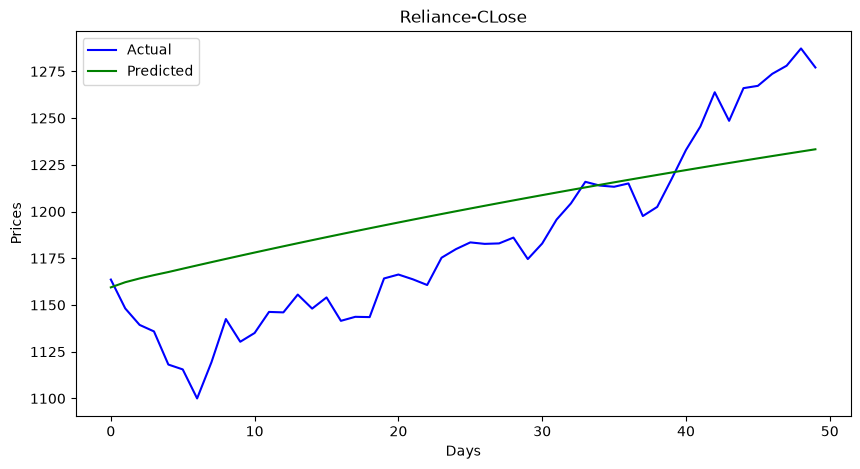

In [35]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","Reliance-CLose","Days","Prices")

In [36]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 33.48326379244148
MAPE-Testset: 0.02494851452442638


In [37]:
forecast=model_fit.predict(len(data1),len(data1)+3)

In [38]:
forecast

array([0.93668187, 0.93799506, 0.93929805, 0.94059097])

In [39]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [40]:
forecast_stock_price_test_oriF.to_csv("Closets.csv",index=False)

In [41]:
forecast_stock_price_test_oriF

,Closefore
0,1234.486177
1,1235.664979
2,1236.834621
3,1237.995233
